# Treinamento e avaliação do Autoencoder

Este notebook apresenta o fluxo completo para:

1. **Carregar os embeddings** (768 dimensões) gerados e agregados por vereador.
2. **Instanciar e treinar um Autoencoder** no PyTorch para comprimir os embeddings para um espaço latente de 64 dimensões.
3. **Visualizar a curva de aprendizado** (loss MSE ao longo das épocas).
4. **Extrair e salvar as representações latentes** (comprimidas) para uso em clusterização e busca por similaridade.
5. **Avaliar a qualidade da reconstrução** comparando os embeddings originais e reconstruídos.


---

## 1. Imports e configurações


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
import sys

# Adiciona o diretório 'src' ao PATH para importar módulos locais
sys.path.append('..')

from autoencoder import Autoencoder, EmbeddingsDataset, extrair_latente

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

---

## 2. Carregamento dos dados


In [16]:
# paths dos arquivos
BASE_DIR = Path("").resolve().parent.parent
EMBEDDINGS_PATH = BASE_DIR / "models" / "embeddings.npy"
META_PATH = BASE_DIR / "models" / "embeddings_meta.csv"

# carrega embeddings e metadados
embeddings = np.load(EMBEDDINGS_PATH)
metadata = pd.read_csv(META_PATH)

print(f"Matriz de embeddings: {embeddings.shape} (vereadores x dimensões)")
print(f"Metadados carregados: {metadata.shape} (candidatos)")
metadata.head()

Matriz de embeddings: (94, 768) (vereadores x dimensões)
Metadados carregados: (94, 2) (candidatos)


,nome,municipio
0,Adriano do Táxi,Bayeux
1,Alexandre do Sindicato,Campina Grande
2,Alysson dos Santos Gomes (Alysson Gomes),Santa Rita
3,Anderson de Lima Liberato (Anderson Liberato),Santa Rita
4,Aninha Cardoso,Campina Grande


### Criando o dataloader para o pytorch


In [17]:
BATCH_SIZE = 16
dataset = EmbeddingsDataset(embeddings)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Número total de batches no DataLoader: {len(dataloader)}")

Número total de batches no DataLoader: 6


---

## 3. Inicialização do autoencoder


In [18]:
# configurando o dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando o dispositivo: {device}")

# instanciando o modelo
model = Autoencoder().to(device)
print(model)

Usando o dispositivo: cpu
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=768, bias=True)
  )
)


In [19]:
# teste rápido de forward pass com um batch
test_batch = next(iter(dataloader)).to(device)
reconstructed = model(test_batch)
print(f"Input batch shape: {test_batch.shape}")
print(f"Reconstructed batch shape: {reconstructed.shape}")

Input batch shape: torch.Size([16, 768])
Reconstructed batch shape: torch.Size([16, 768])


---

## 4. Treinamento do modelo


In [20]:
EPOCHS = 200
LEARNING_RATE = 1e-3

criterio = nn.MSELoss()
otimizador = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
historico_loss = []

model.train()
print("Iniciando loop de treinamento...")
for epoca in range(1, EPOCHS + 1):
    loss_total = 0.0
    for batch in dataloader:
        batch = batch.to(device)
        
        # Forward pass
        reconstrucao = model(batch)
        loss = criterio(reconstrucao, batch)
        
        # Backward pass
        otimizador.zero_grad()
        loss.backward()
        otimizador.step()
        
        loss_total += loss.item()
        
    loss_media = loss_total / len(dataloader)
    historico_loss.append(loss_media)
    
    if epoca % 20 == 0 or epoca == 1:
        print(f"Época {epoca:>3d}/{EPOCHS} | Loss (MSE): {loss_media:.6f}")

Iniciando loop de treinamento...


Época   1/200 | Loss (MSE): 0.002416
Época  20/200 | Loss (MSE): 0.000344
Época  40/200 | Loss (MSE): 0.000109
Época  60/200 | Loss (MSE): 0.000047
Época  80/200 | Loss (MSE): 0.000025
Época 100/200 | Loss (MSE): 0.000013
Época 120/200 | Loss (MSE): 0.000010
Época 140/200 | Loss (MSE): 0.000008
Época 160/200 | Loss (MSE): 0.000010
Época 180/200 | Loss (MSE): 0.000005
Época 200/200 | Loss (MSE): 0.000003


### Visualização da curva de Loss


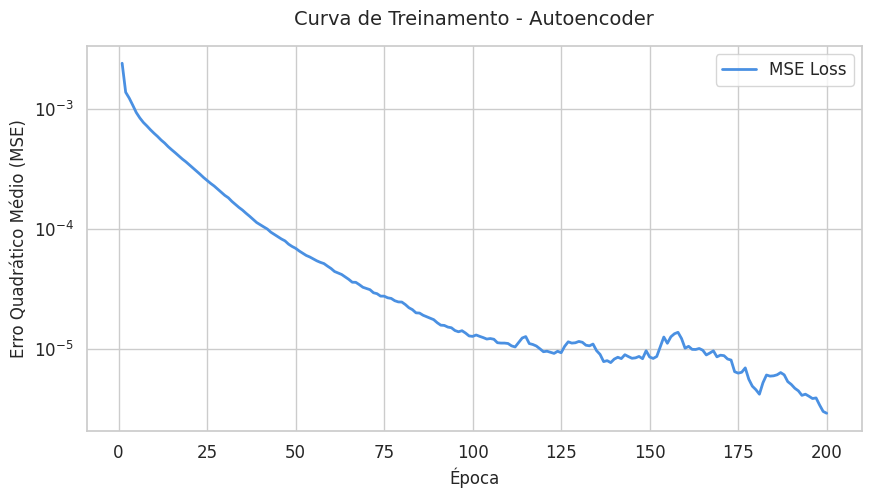

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), historico_loss, color='#4A90E2', lw=2, label='MSE Loss')
plt.title('Curva de Treinamento - Autoencoder', fontsize=14, pad=15)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Quadrático Médio (MSE)', fontsize=12)
plt.yscale('log') # Escala logarítmica para ver melhor a convergência
plt.legend()
plt.show()

---

## 5. Extração das representações Latentes


In [26]:
# extrai as representações latentes utilizando a função utilitária do script local
latent = extrair_latente(model, embeddings)
print(f"Embeddings originais: {embeddings.shape}")
print(f"Espaço latente comprimido: {latent.shape}")

Embeddings originais: (94, 768)
Espaço latente comprimido: (94, 64)


---

## 6. Avaliação da qualidade da reconstrução


In [27]:
# Avalia a reconstrução no conjunto todo
model.eval()
with torch.no_grad():
    tensores = torch.tensor(embeddings, dtype=torch.float32).to(device)
    reconstrucao_completa = model(tensores).cpu().numpy()

# Calcula MSE médio por elemento
mse = np.mean((embeddings - reconstrucao_completa) ** 2)
print(f"MSE médio geral de reconstrução: {mse:.6f}")

# Calcula a similaridade cosseno média entre o original e a reconstrução
cos_sims = []
for i in range(len(embeddings)):
    orig = embeddings[i]
    rec = reconstrucao_completa[i]
    sim = np.dot(orig, rec) / (np.linalg.norm(orig) * np.linalg.norm(rec))
    cos_sims.append(sim)

print(f"Similaridade cosseno média (Original vs Reconstruído): {np.mean(cos_sims):.4f}")

MSE médio geral de reconstrução: 0.000002
Similaridade cosseno média (Original vs Reconstruído): 0.9991


### Gráfico de distribuição do erro de reconstrução


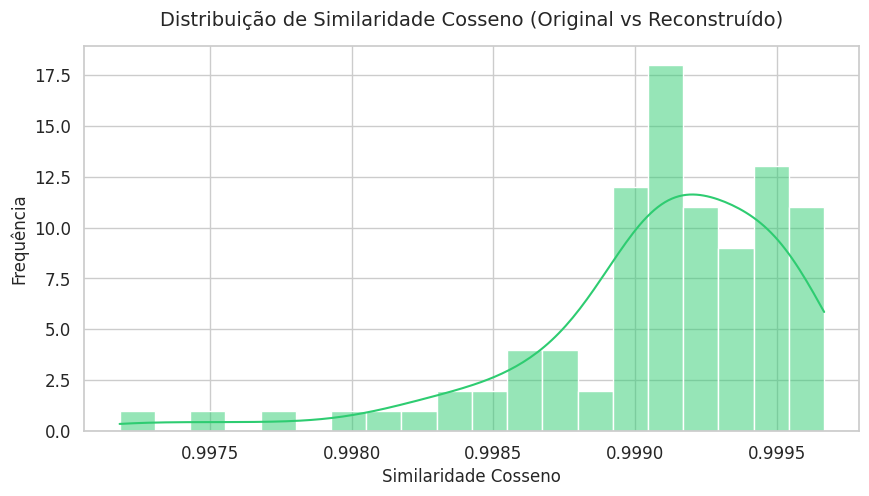

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(cos_sims, kde=True, color='#2ECC71', bins=20)
plt.title('Distribuição de Similaridade Cosseno (Original vs Reconstruído)', fontsize=14, pad=15)
plt.xlabel('Similaridade Cosseno', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.show()

---

## 7. Salvamento do modelo e latente


In [25]:
# Define caminhos para salvamento
MODEL_SAVE_PATH = BASE_DIR / "models" / "autoencoder.pt"
LATENT_SAVE_PATH = BASE_DIR / "models" / "latent.npy"

# Salva os pesos
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Pesos do autoencoder salvos em: {MODEL_SAVE_PATH}")

# Salva a representação latente
np.save(LATENT_SAVE_PATH, latent)
print(f"Representações latentes salvas em: {LATENT_SAVE_PATH}")

Pesos do autoencoder salvos em: /home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/models/autoencoder.pt
Representações latentes salvas em: /home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/models/latent.npy
